# 石墨烯与 MoS₂：从 FC2 拟合到旋转条件

用两种单层材料的预计算力拟合 FC2，在同一份拟合结果上施加旋转修正，再比较声子谱。每种材料只拟合一次，便于看清修正本身的影响。

结构与训练文件位于 `data/rotational-sum-rules/`；无需外部 calculator。环境准备见[教程总览](index.md)。

## 1. 读取石墨烯的结构

石墨烯参考超胞为 $7\times7\times1$，真空方向仍采用周期边界。本例恢复二阶力常数：8 Å 是教学截断，足以在这个超胞内保留一组近邻相互作用，实际研究仍要检查收敛。

先把结构和数据路径集中起来。换材料时，需要一份参考晶胞、一份匹配的理想超胞和保持相同原子顺序的训练帧。

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
from ase.io import read
from ase.calculators.singlepoint import SinglePointCalculator
from mlfcs import ClusterSpace, ClusterMap, ForceDataset, FitSystem
from mlfcs.phonon import Harmonic

logging.getLogger("mlfcs").setLevel(logging.WARNING)
DATA = Path("data/rotational-sum-rules")
if not DATA.exists():
    DATA = Path("docs/notebooks") / DATA
primitive = read(DATA / "graphene/primitive.vasp")
supercell = read(DATA / "graphene/supercell.vasp")
print(f"石墨烯：参考晶胞 {len(primitive)} 原子，超胞 {len(supercell)} 原子")

石墨烯：参考晶胞 2 原子，超胞 98 原子


## 2. 选择模型并连接到超胞

`asr=True` 在初始化时准备满足平移不变性的拟合坐标；不是拟合完成后的 ASR 修补。二阶默认体阶为 2，这里不用重复指定。

`ClusterMap` 从晶胞关系推断超胞矩阵。可辨识性检查只依赖模型与超胞，不依赖训练帧数。

In [2]:
space = ClusterSpace(primitive, cutoffs={2: 8.0}, asr=True)
mapping = ClusterMap(space, supercell)
mapping.rank_info().require_full()
print(f"物理参数：{space.n_parameters}；ASR 自由参数：{space.n_free_parameters}")

物理参数：54；ASR 自由参数：52


## 3. 把石墨烯的位移文件还原成带力结构

这份石墨烯文件的 `positions` 是占位数据，真实扰动保存在 `displacements` 中。因此必须从理想超胞复制结构、加上位移，再把文件里的力挂到新结构上。`SinglePointCalculator` 只保存结果，不重新计算力。

普通 ASE 带力轨迹通常已经包含正确位置，不需要这一步转换；后面的 MoS₂ 就是这种情况。

In [3]:
frames = read(DATA / "graphene/training.extxyz", index=":")
structures = []
for frame in frames:
    atoms = supercell.copy()
    atoms.positions += frame.arrays["displacements"]
    atoms.calc = SinglePointCalculator(atoms, forces=frame.get_forces())
    structures.append(atoms)
dataset = ForceDataset(mapping, structures)
print(f"石墨烯带力样本：{len(dataset.forces)} 帧")

石墨烯带力样本：1 帧


## 4. 拟合，然后施加旋转条件

用正规方程保存力观测，避免保留完整设计矩阵。`solve()` 使用默认列缩放与迭代容差；训练误差用来检查模型对这批力的解释程度。

Born–Huang 条件适用于力平衡参考结构；`huang=True` 进一步要求零应力。本例以这一物理前提演示两组条件，不能对任意受力、受应力结构照搬。旋转修正保持已有 ASR 残差，只改变 FC2。默认奇异值截断由几何误差估计，残差不保证严格为零。

In [4]:
system = FitSystem(dataset, representation="normal")
graphene_model = system.solve()
graphene_rotation = graphene_model.enforce_rotation(born_huang=True, huang=True)
print(f"石墨烯力相对误差：{system.relative_error(graphene_model):.3%} → "
      f"{system.relative_error(graphene_rotation.force_constants):.3%}")
print(f"旋转相对残差：{graphene_rotation.relative_before:.2e} → "
      f"{graphene_rotation.relative_after:.2e}")

石墨烯力相对误差：1.051% → 1.051%
旋转相对残差：1.30e-05 → 4.61e-19


## 5. 用同样的步骤处理 MoS₂

MoS₂ 的 $8\times8\times1$ 超胞训练帧已经存有正确位置和力，直接交给 `ForceDataset` 即可。模型仍使用 8 Å 截断与 ASR，然后在同一份结果上进行旋转修正。

如果替换自己的二维材料，除了结构和训练帧，还要检查真空厚度、截断以及参考结构是否满足力平衡和零应力。

In [5]:
mos2_primitive = read(DATA / "mos2/primitive.vasp")
mos2_supercell = read(DATA / "mos2/supercell.vasp")
mos2_space = ClusterSpace(mos2_primitive, cutoffs={2: 8.0}, asr=True)
mos2_mapping = ClusterMap(mos2_space, mos2_supercell)
mos2_mapping.rank_info().require_full()
mos2_dataset = ForceDataset(mos2_mapping, read(DATA / "mos2/training.extxyz", index=":"))
print(f"MoS₂：参考晶胞 {len(mos2_primitive)} 原子，超胞 {len(mos2_supercell)} 原子；"
      f"训练样本 {len(mos2_dataset.forces)} 帧")

MoS₂：参考晶胞 3 原子，超胞 192 原子；训练样本 5 帧


数据准备好后，求解与修正的调用和石墨烯相同。误差的变化可以帮助判断施加约束对训练数据造成了多大影响；误差降低并不是旋转修正的目标。

In [6]:
mos2_system = FitSystem(mos2_dataset, representation="normal")
mos2_model = mos2_system.solve()
mos2_rotation = mos2_model.enforce_rotation(born_huang=True, huang=True)
print(f"MoS₂ 力相对误差：{mos2_system.relative_error(mos2_model):.3%} → "
      f"{mos2_system.relative_error(mos2_rotation.force_constants):.3%}")
print(f"旋转相对残差：{mos2_rotation.relative_before:.2e} → "
      f"{mos2_rotation.relative_after:.2e}")

MoS₂ 力相对误差：10.054% → 10.055%
旋转相对残差：4.97e-05 → 7.14e-09


## 6. 沿平面内路径比较声子谱

两种模型使用完全相同的 Γ–M–K–Γ 路径。这里明确给出分数倒坐标，避免自动三维路径包含真空方向；300 个取样点用于观察低频支的变化。

每种材料左右两幅图分别是 ASR 拟合与加入旋转修正的结果。负频率表示虚频。是否满足物理条件应结合前面的残差检查，不能只根据曲线形状判断。

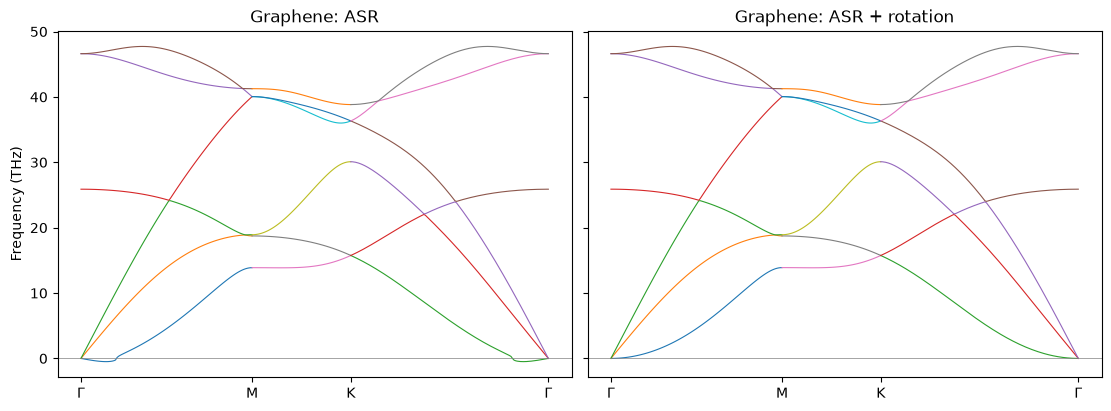

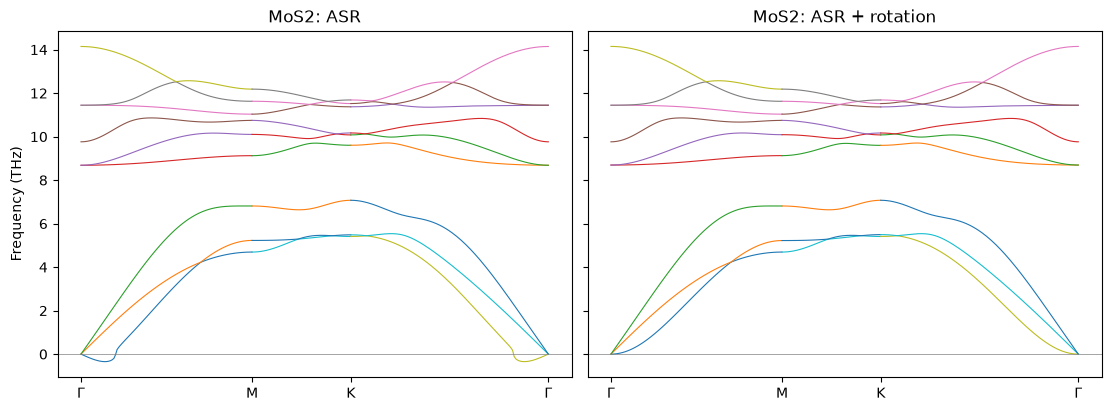

In [7]:
comparisons = [
    ("Graphene", graphene_model, graphene_rotation.force_constants),
    ("MoS2", mos2_model, mos2_rotation.force_constants),
]
special_points = {"G": (0, 0, 0), "M": (0.5, 0, 0), "K": (1 / 3, 1 / 3, 0)}
for name, fitted, corrected in comparisons:
    path = fitted.cluster_space.primitive_atoms.cell.bandpath(
        "GMKG", special_points=special_points, npoints=300,
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, constrained_layout=True)
    for axis, model, title in zip(axes, (fitted, corrected), ("ASR", "ASR + rotation")):
        bands = Harmonic(model).run_band_path(path)
        for segment in bands.segments:
            axis.plot(bands.distances[segment], bands.frequencies_thz[segment], lw=0.8)
        axis.set_xticks(bands.tick_positions, bands.tick_labels)
        axis.axhline(0, color="0.5", lw=0.5)
        axis.set_title(f"{name}: {title}")
    axes[0].set_ylabel("Frequency (THz)")
    plt.show()

## 接下来

我们为每种材料完成了一次 ASR 约束拟合，在不重新拟合的情况下加入旋转条件，并比较了力误差、约束残差和声子谱。两种材料对修正的响应不必相同，也不预设训练误差会改善。

替换自己的材料时，先确认数据的位置表示和原子顺序，再选择 cutoff，并确认是否可以采用零应力 Huang 条件。数学约定见[平移与旋转不变性](../theory/invariance-constraints.md)。

下一份 [Si 有限差分教程](si-finite-difference.ipynb)从生成位移结构开始，演示如何自己计算力并恢复 FC2、FC3。